# Part A: Understanding the Dataset 
### Q1. Dataset Overview|

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("agriculture_yield_dataset.csv")

# Display first 10 records
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [2]:
# Number of rows and columns
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1500, 8)


In [3]:
# Display all column names
print(df.columns)

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


### Q2. Data Types and Missing Values 

In [4]:
# Display data types
print(df.dtypes)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object


In [5]:
# Check missing values
print(df.isnull().sum())

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


**No missing values are present in the dataset.**

### Q3. Descriptive Statistics 

In [7]:
# Generate descriptive statistics
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [8]:
# Find feature with highest mean

highest_mean = df.describe().loc['mean'].idxmax()

print("Feature with Highest Mean:", highest_mean)

Feature with Highest Mean: rainfall_mm


In [9]:
# Find feature with highest standard deviation

highest_std = df.describe().loc['std'].idxmax()

print("Feature with Highest Standard Deviation:", highest_std)

Feature with Highest Standard Deviation: rainfall_mm


# Part B: Exploratory Data Analysis (EDA) 
### Q4. Distribution Analysis

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

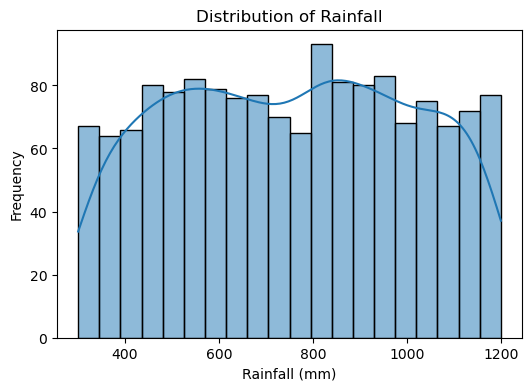

In [11]:
# Histogram for rainfall_mm

plt.figure(figsize=(6,4))
sns.histplot(df['rainfall_mm'], bins=20, kde=True)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

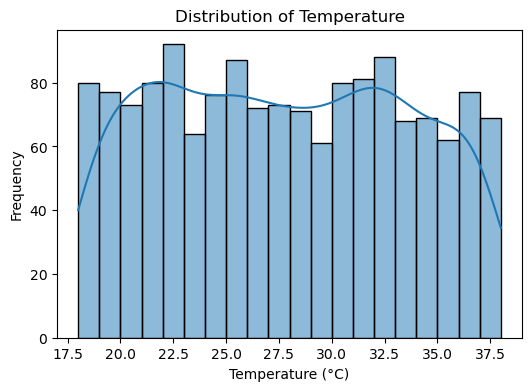

In [12]:
# Histogram for temperature_c

plt.figure(figsize=(6,4))
sns.histplot(df['temperature_c'], bins=20, kde=True)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

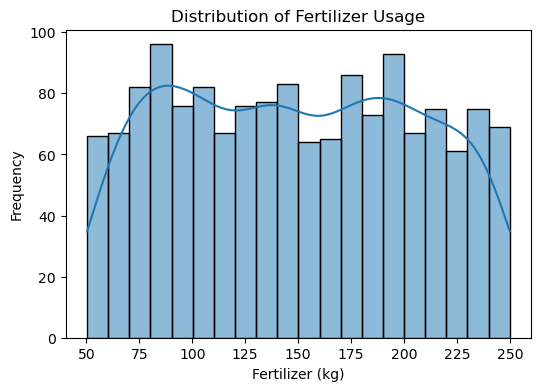

In [13]:
# Histogram for fertilizer_kg

plt.figure(figsize=(6,4))
sns.histplot(df['fertilizer_kg'], bins=20, kde=True)

plt.title("Distribution of Fertilizer Usage")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")

plt.show()

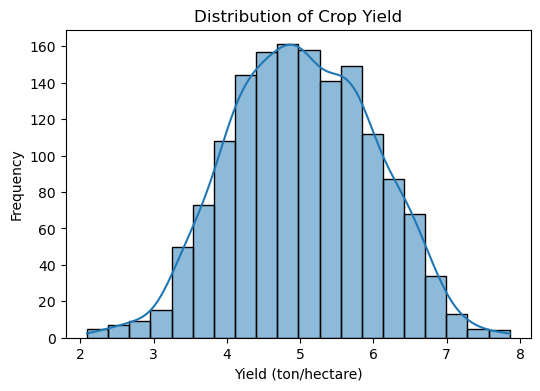

In [14]:
# Histogram for yield_ton_per_hectare

plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], bins=20, kde=True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (ton/hectare)")
plt.ylabel("Frequency")

plt.show()

### Observations

#### Rainfall Histogram
- Rainfall values appear moderately distributed.
- Most observations are concentrated around the middle range.
- Very few extreme rainfall values are visible.

#### Temperature Histogram
- Temperature values show an approximately normal distribution.
- Most temperatures are clustered near the average.
- No major outliers are visible.

#### Fertilizer Histogram
- Fertilizer usage appears evenly distributed.
- Some variation exists among farms.
- Extreme fertilizer values are limited.

#### Yield Histogram
- Crop yield distribution is close to normal.
- Most yield values fall within the central range.
- A few possible outliers may be present.

### Q5. Crop Type Analysis 

In [16]:
# Count records for each crop type

crop_counts = df['crop_type'].value_counts()

print(crop_counts)

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


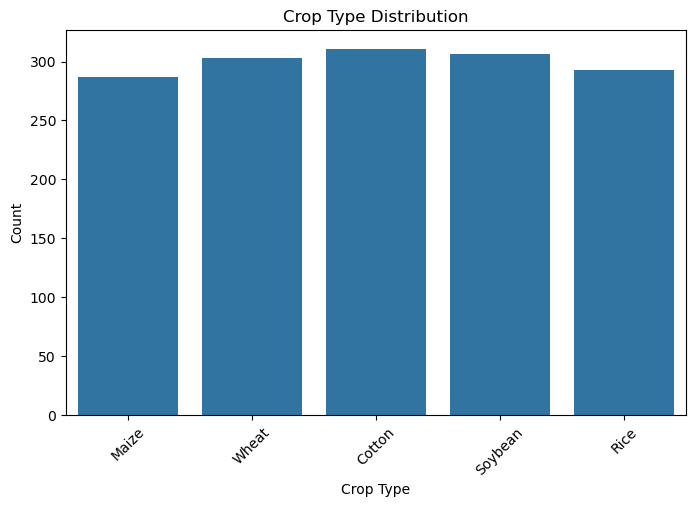

In [17]:
# Count plot for crop_type

plt.figure(figsize=(8,5))

sns.countplot(x='crop_type', data=df)

plt.title("Crop Type Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [18]:
# Most frequent crop type

most_common_crop = df['crop_type'].mode()[0]

print("Most Frequent Crop Type:", most_common_crop)

Most Frequent Crop Type: Cotton


#### Observations

- The count plot shows the distribution of different crop types in the dataset.
- Some crops appear more frequently than others.
- The most common crop type is the one with the highest number of records.

### Q6. Soil Type Analysis

In [20]:
# Frequency of each soil type

soil_counts = df['soil_type'].value_counts()

print(soil_counts)

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


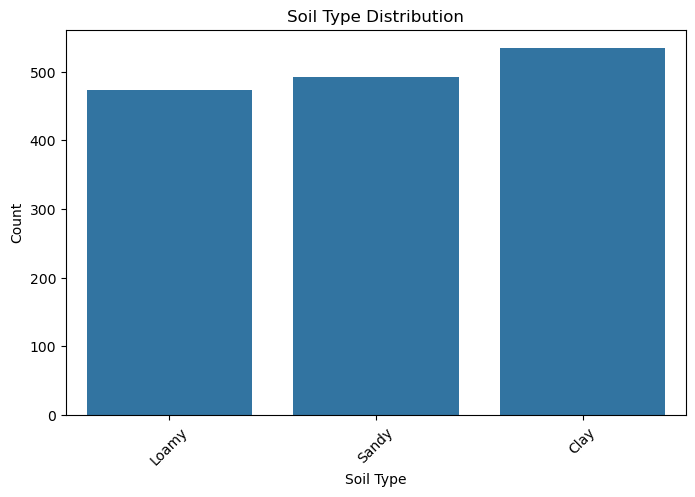

In [22]:
# Count plot for soil_type

plt.figure(figsize=(8,5))

sns.countplot(x='soil_type', data=df)

plt.title("Soil Type Distribution")
plt.xlabel("Soil Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [23]:
# Most common soil type

most_common_soil = df['soil_type'].mode()[0]

print("Most Common Soil Type:", most_common_soil)

Most Common Soil Type: Clay


#### Observations

- The dataset contains multiple soil types with varying frequencies.
- Some soil types occur more frequently than others.
- The most common soil type is the one with the highest count in the dataset.

### Q7. Yield Distribution 

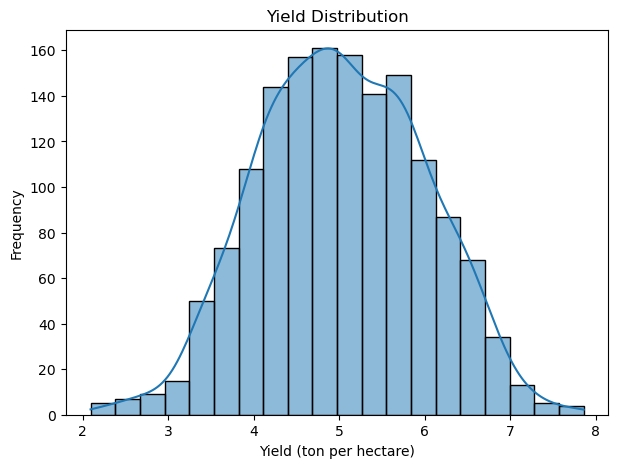

In [24]:
# Histogram for yield_ton_per_hectare

plt.figure(figsize=(7,5))

sns.histplot(df['yield_ton_per_hectare'], bins=20, kde=True)

plt.title("Yield Distribution")
plt.xlabel("Yield (ton per hectare)")
plt.ylabel("Frequency")

plt.show()

#### Observations

- The distribution of yield_ton_per_hectare appears approximately normal.
- Most yield values are concentrated around the middle range.
- A few extreme values may indicate possible outliers.
- The histogram shows moderate variation in crop yield.


#### Is the distribution approximately normal?
Yes, the distribution of `yield_ton_per_hectare` appears approximately normal because most values are concentrated around the center.

#### Are there any noticeable outliers?
A few possible outliers may be present at the extreme ends of the histogram.

### Q8. Scatter Plot Analysis

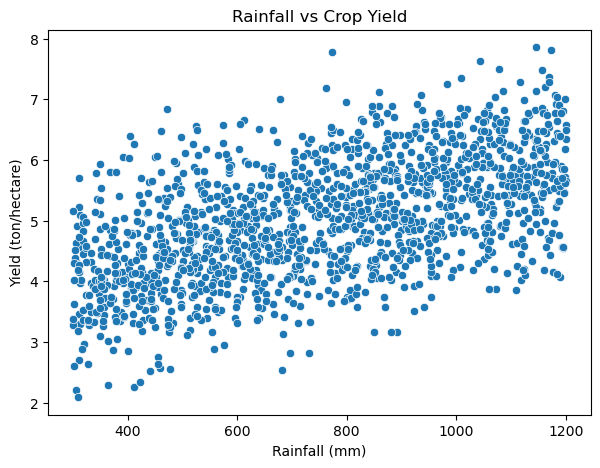

In [26]:
# Scatter plot: rainfall_mm vs yield_ton_per_hectare

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (ton/hectare)")

plt.show()

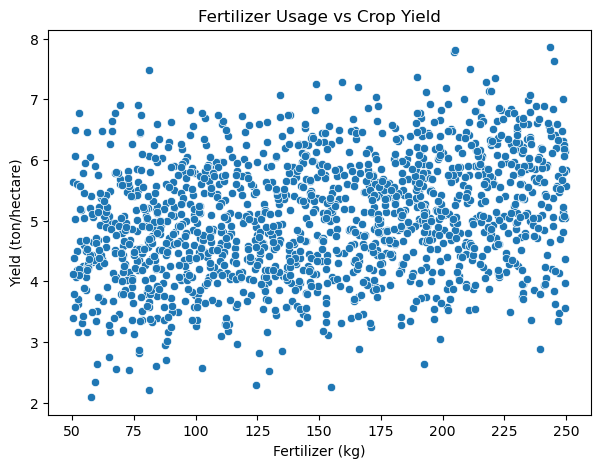

In [27]:
# Scatter plot: fertilizer_kg vs yield_ton_per_hectare

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield (ton/hectare)")

plt.show()

#### Observations

- Both rainfall and fertilizer usage show a positive relationship with crop yield.
- As rainfall and fertilizer usage increase, crop yield tends to increase.
- The fertilizer_kg feature appears to have a stronger relationship with yield because the data points show a clearer upward trend.

### Q9. Correlation Analysis

In [28]:
# Correlation matrix for numerical features

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

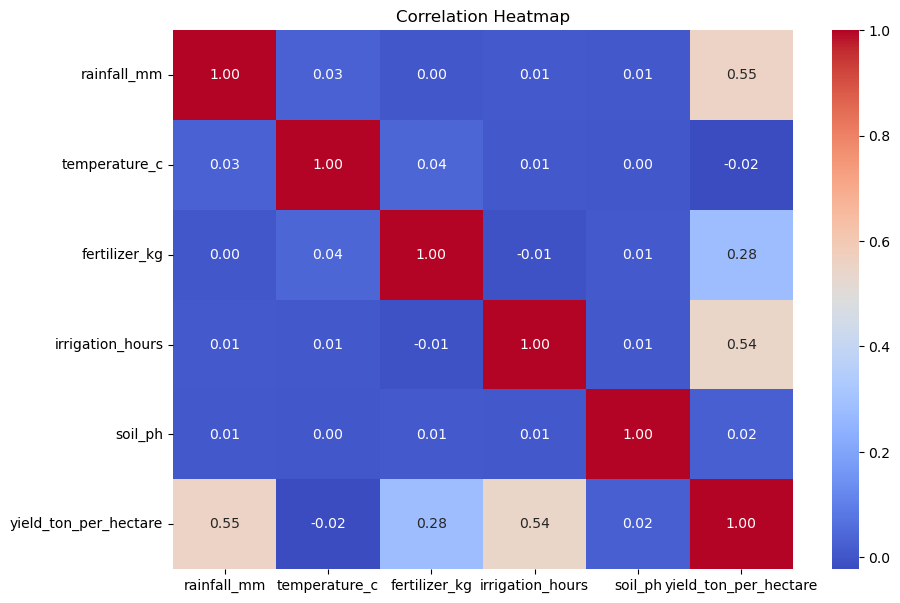

In [29]:
# Heatmap of correlation matrix

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
# Correlation with yield_ton_per_hectare

yield_correlation = correlation_matrix['yield_ton_per_hectare'].sort_values(ascending=False)

print(yield_correlation)

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


#### Observations

- The heatmap shows the relationships between numerical features.
- Features with higher positive correlation values have a stronger positive relationship with crop yield.
- The top three features most correlated with `yield_ton_per_hectare` can be identified from the correlation values.
- Fertilizer usage and rainfall generally show positive correlation with crop yield.

### Q10. Group-Based Analysis 

In [32]:
# Average yield for each crop type

crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print(crop_yield)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [33]:
# Average yield for each soil type

soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print(soil_yield)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [34]:
# Crop type with highest average yield

best_crop = crop_yield.idxmax()

print("Crop Type with Highest Average Yield:", best_crop)

Crop Type with Highest Average Yield: Rice


In [35]:
# Soil type with highest average yield

best_soil = soil_yield.idxmax()

print("Soil Type with Highest Average Yield:", best_soil)

Soil Type with Highest Average Yield: Loamy


#### Observations

- Different crop types produce different average yields.
- Yield also varies depending on soil type.
- The crop type with the highest average yield performs best under the given conditions.
- The soil type with the highest average yield appears most suitable for agricultural productivity.

# Part C: Data Preparation 
### Q11. Feature Encoding

In [36]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')


In [37]:
# Convert categorical variables using One-Hot Encoding

df_encoded = pd.get_dummies(df, columns=categorical_columns)

print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_Wheat  soil_type_Clay  soil_type_Loamy  \


In [38]:
# Display first five rows

df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


#### Observations

- The dataset contains categorical variables such as crop type and soil type.
- One-Hot Encoding converts categorical values into numerical columns.
- The transformed dataset is now suitable for machine learning algorithms.

#### Q12. Feature Selection

In [39]:
# Define input features and target variable

X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Input Features (X):
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Cotton  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0             False             True           False              False   
1             False             True           False              False   
2             False            False           False              False   
3             False             True           False              False   
4              True            False           False              False   

   crop_type_Wheat  soil_type_Clay  soil_type_Loamy  soil_type_Sandy  
0      

#### Feature Selection

- The input features (`X`) contain all independent variables used for prediction.
- The target variable (`y`) is `yield_ton_per_hectare`.
- The model will learn patterns from the input features to predict crop yield.

#### Q13. Train-Test Split

In [40]:
from sklearn.model_selection import train_test_split

In [43]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
# Display shapes of train-test datasets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 13)
X_test shape: (300, 13)
y_train shape: (1200,)
y_test shape: (300,)


#### Train-Test Split

- The dataset was divided into training and testing sets.
- 80% of the data was used for training the model.
- 20% of the data was used for testing the model.
- The training data helps the model learn patterns, while the testing data evaluates model performance.

#### Q14. Linear Regression Model

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
# Create Linear Regression model

lr_model = LinearRegression()

# Train the model

lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [46]:
# Display coefficients and intercept

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print(coefficients)

print("\nIntercept:", lr_model.intercept_)

              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280

Intercept: 1.9111026182800694


In [47]:
# Feature with highest positive coefficient

highest_positive_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print("Feature with Highest Positive Coefficient:")
print(highest_positive_feature)

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object


#### Linear Regression Model

- A Linear Regression model wa|s trained to predict crop yield.
- The coefficients show how each feature affects crop yield.
- Positive coefficients indicate a direct relationship with yield.
- The feature with the highest positive coefficient has the strongest positive impact on crop yield.